<a href="https://colab.research.google.com/github/chiragdeepmaan/Deep_Learning/blob/main/Euronet_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install -q opencv-python
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 757.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 94.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [15]:
import tensorflow as tf
print(tf.__version__)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


2.21.0


In [ ]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
 89% 1.83G/2.04G [00:14<00:01, 153MB/s]

In [6]:
import zipfile

with zipfile.ZipFile("eurosat-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [7]:
# importing necessary libraries

import numpy as np
import matplotlib.pyplot as plt


In [8]:
import os

print(os.listdir("dataset"))

['EuroSATallBands', 'EuroSAT']


In [9]:
print(os.listdir("dataset/EuroSAT"))

['label_map.json', 'Forest', 'AnnualCrop', 'SeaLake', 'HerbaceousVegetation', 'Residential', 'Pasture', 'train.csv', 'Highway', 'PermanentCrop', 'test.csv', 'River', 'Industrial', 'validation.csv']


In [10]:
from pathlib import Path

dataset_path = Path("dataset/EuroSAT")

images = list(dataset_path.glob("*/*.jpg"))

print("Total Images:", len(images))

Total Images: 27000


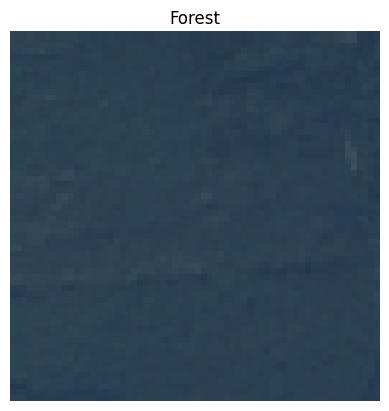

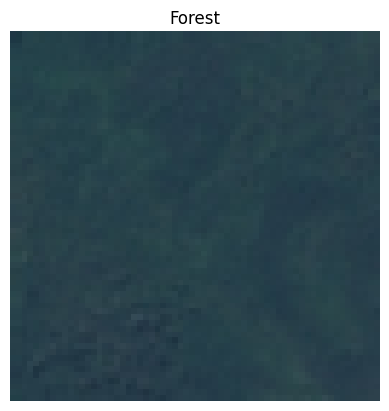

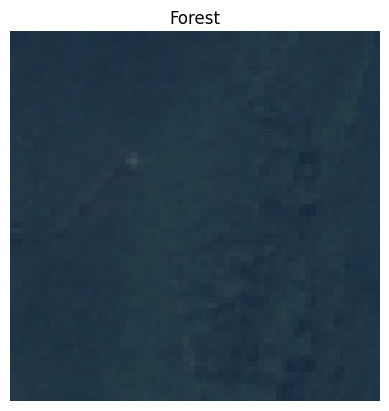

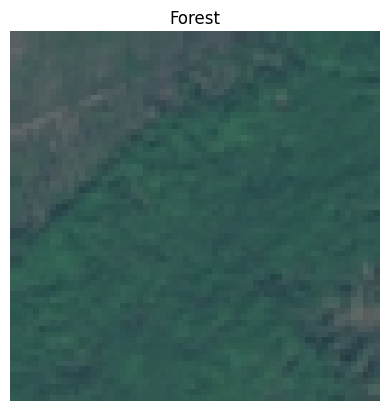

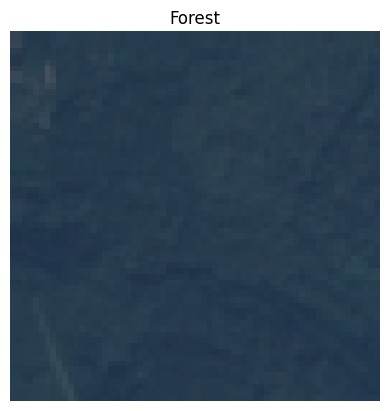

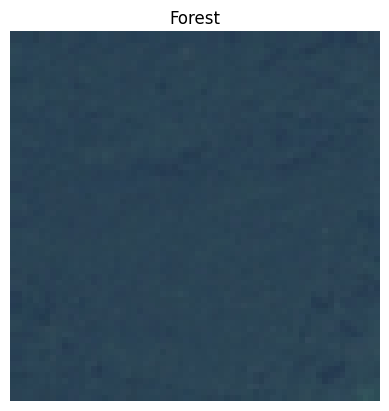

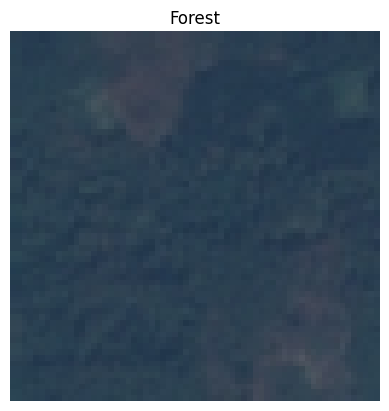

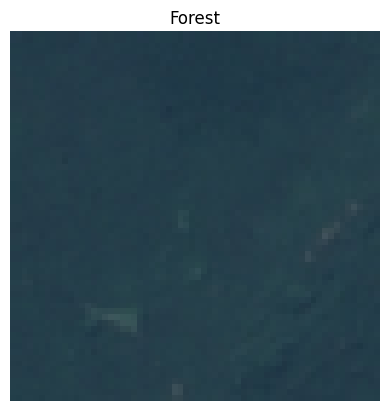

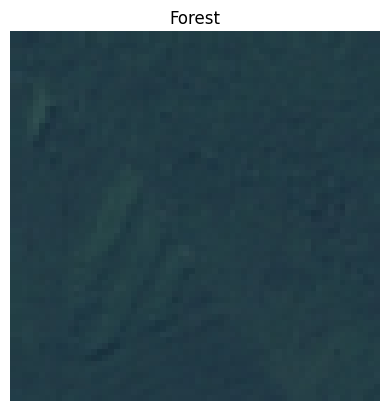

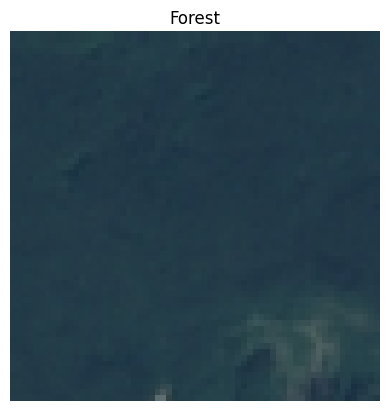

In [17]:
import cv2
import matplotlib.pyplot as plt

for i in range(10):
  img_path = images[i]

  img = cv2.imread(str(img_path))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.imshow(img)
  plt.title(img_path.parent.name)
  plt.axis("off")
  plt.show()

In [16]:
import tensorflow as tf

train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/EuroSAT",
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(64,64),
    batch_size=32)

val_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/EuroSAT",
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(64,64),
    batch_size=32
)


Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [18]:
type(train_dataset)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [19]:
print(train_dataset.class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


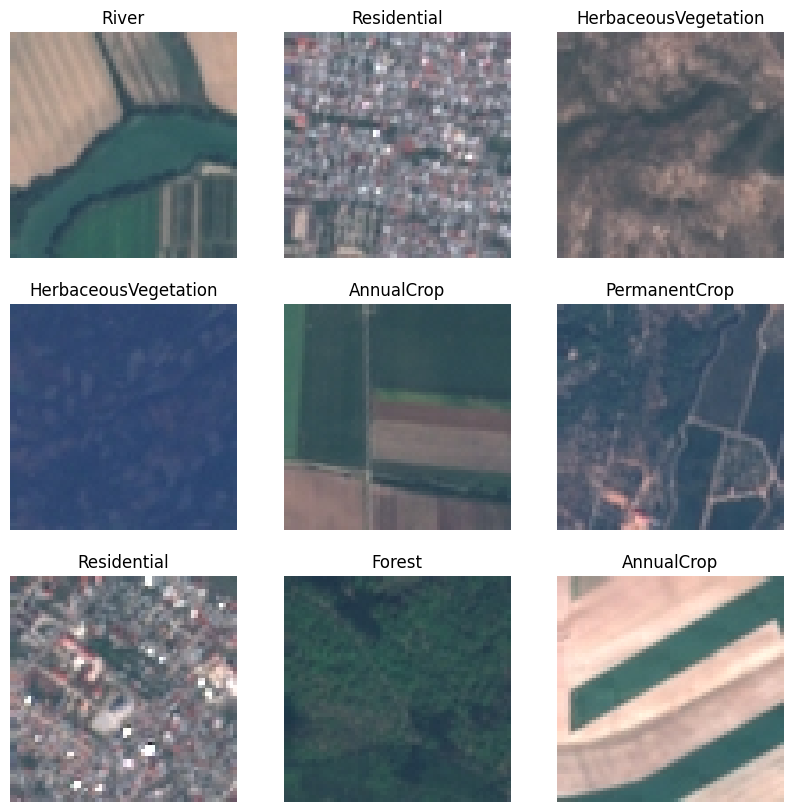

In [20]:
import matplotlib.pyplot as plt

class_names = train_dataset.class_names

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [21]:
for image,labels in train_dataset:
  print(image.shape)
  print(labels.shape)
  break

(32, 64, 64, 3)
(32,)


In [22]:
# image normalization
normalization_layer=tf.keras.layers.Rescaling(1./255)

train_dataset=train_dataset.map(lambda x,y:(normalization_layer(x),y))
val_dataset=val_dataset.map(lambda x,y:(normalization_layer(x),y))

In [23]:
# data augumentation

data_augumentation=tf.keras.Sequential([

                                        tf.keras.layers.RandomFlip("horizontal"),
                                        tf.keras.layers.RandomRotation(0.15),
                                        tf.keras.layers.RandomZoom(0.15),
                                        tf.keras.layers.RandomContrast(0.10),
                                        tf.keras.layers.RandomTranslation(0.10,0.10)


])

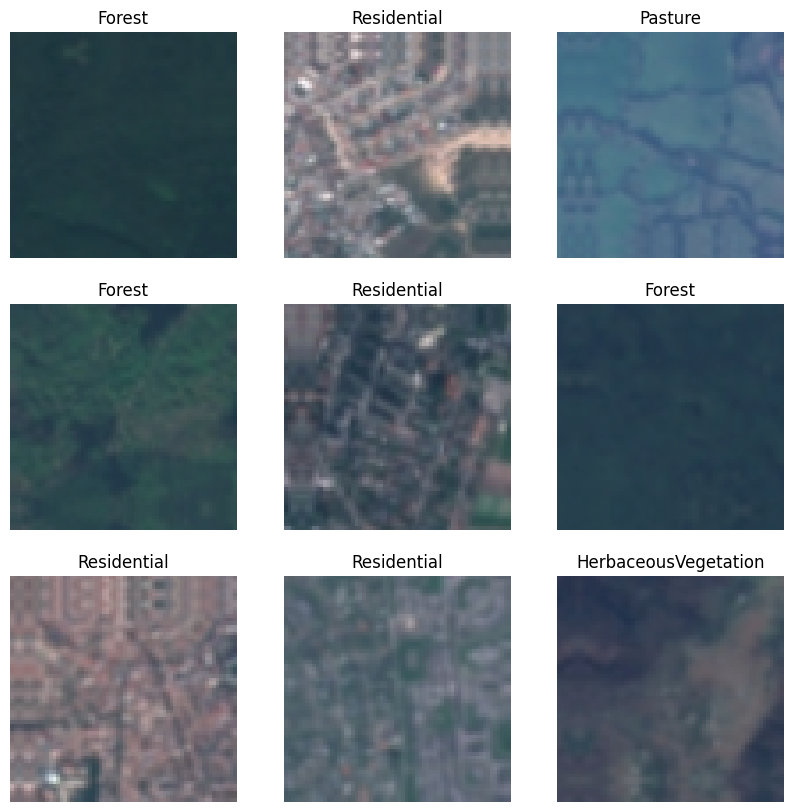

In [24]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(1):
  augumented_images=data_augumentation(images)

  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(augumented_images[i])

    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()


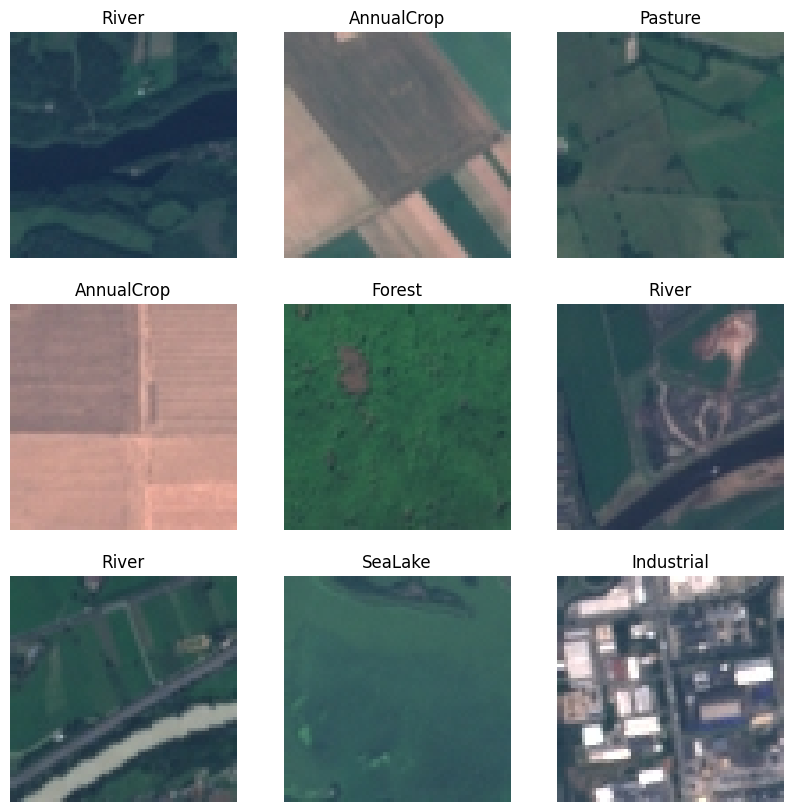

In [25]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(2):
  # augumented_images=data_augumentation(images)

  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()


In [26]:
AUTOTUNE=tf.data.AUTOTUNE

train_dataset=train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)

val_dataset=val_dataset.cache().prefetch(AUTOTUNE)

In [27]:
for image,label in train_dataset.take(1):

  print("Max pixels",tf.reduce_max(image).numpy())
  print("Min pixels",tf.reduce_min(image).numpy())

  print("Batch Shape",image.shape)
  print("Label Shape",label.shape)

Max pixels 1.0
Min pixels 0.07058824
Batch Shape (32, 64, 64, 3)
Label Shape (32,)


In [28]:
# model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense


model=Sequential()
# data augumentation
model.add(data_augumentation)
# convolution layer 1
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu',input_shape=(64,64,3)))
# batch normalization
model.add(BatchNormalization())
# maxpooling
model.add(MaxPooling2D(pool_size=(2,2),strides=2))
# dropout
model.add(Dropout(0.2))
# convolution layer 2
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2),strides=2))

model.add(Dropout(0.3))

model.add(Conv2D(filters=128,kernel_size=(3,3),strides=(1,2),padding='same',activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2),strides=2))

model.add(Dropout(0.4))
# fully connected layer

model.add(Flatten())

model.add(Dense(units=256,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(units=128,activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(units=10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 64, 64, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 64, 64, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 64, 64, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 32, 32, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 32, 32, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 32, 32, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 32, 32, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 16, 16, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 16, 16, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 16, 8, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 16, 8, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 8, 4, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 8, 4, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 4096)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 256)              │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,177,162 (4.49 MB)

 Trainable params: 1,176,714 (4.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
# compiler
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
# callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop=EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1,
    mode='max',
    restore_best_weights=True
)

checkpoint=ModelCheckpoint(
    filepath='model.h5',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

In [32]:
print(model.input_shape)
print(model.output_shape)

(32, 64, 64, 3)
(32, 10)


In [33]:
history=model.fit(train_dataset,epochs=20,validation_data=val_dataset,callbacks=[early_stop,checkpoint])

Epoch 1/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3348 - loss: 2.1624
Epoch 1: val_accuracy improved from None to 0.52130, saving model to model.h5



Epoch 1: finished saving model to model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 123s 179ms/step - accuracy: 0.4132 - loss: 1.7335 - val_accuracy: 0.5213 - val_loss: 1.2953
Epoch 2/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5382 - loss: 1.3241
Epoch 2: val_accuracy did not improve from 0.52130
675/675 ━━━━━━━━━━━━━━━━━━━━ 122s 181ms/step - accuracy: 0.5632 - loss: 1.2511 - val_accuracy: 0.3991 - val_loss: 2.2915
Epoch 3/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6132 - loss: 1.1024
Epoch 3: val_accuracy did not improve from 0.52130
675/675 ━━━━━━━━━━━━━━━━━━━━ 117s 174ms/step - accuracy: 0.6310 - loss: 1.0535 - val_accuracy: 0.3078 - val_loss: 2.7501
Epoch 4/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6566 - loss: 0.9850
Epoch 4: val_accuracy improved from 0.52130 to 0.58222, saving model to model.h5



Epoch 4: finished saving model to model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 117s 174ms/step - accuracy: 0.6631 - loss: 0.9611 - val_accuracy: 0.5822 - val_loss: 1.1087
Epoch 5/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6908 - loss: 0.8947
Epoch 5: val_accuracy did not improve from 0.58222
675/675 ━━━━━━━━━━━━━━━━━━━━ 113s 168ms/step - accuracy: 0.6903 - loss: 0.8957 - val_accuracy: 0.2909 - val_loss: 3.1793
Epoch 6/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7072 - loss: 0.8533
Epoch 6: val_accuracy improved from 0.58222 to 0.65074, saving model to model.h5



Epoch 6: finished saving model to model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 117s 174ms/step - accuracy: 0.7079 - loss: 0.8556 - val_accuracy: 0.6507 - val_loss: 0.9195
Epoch 7/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7172 - loss: 0.8081
Epoch 7: val_accuracy improved from 0.65074 to 0.75278, saving model to model.h5



Epoch 7: finished saving model to model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 177ms/step - accuracy: 0.7202 - loss: 0.8123 - val_accuracy: 0.7528 - val_loss: 0.7281
Epoch 8/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7404 - loss: 0.7642
Epoch 8: val_accuracy improved from 0.75278 to 0.80352, saving model to model.h5



Epoch 8: finished saving model to model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 113s 167ms/step - accuracy: 0.7385 - loss: 0.7718 - val_accuracy: 0.8035 - val_loss: 0.5512
Epoch 9/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7557 - loss: 0.7219
Epoch 9: val_accuracy did not improve from 0.80352
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 179ms/step - accuracy: 0.7516 - loss: 0.7349 - val_accuracy: 0.4376 - val_loss: 2.1151
Epoch 10/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7566 - loss: 0.7206
Epoch 10: val_accuracy did not improve from 0.80352
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 177ms/step - accuracy: 0.7575 - loss: 0.7209 - val_accuracy: 0.5480 - val_loss: 1.7316
Epoch 11/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7675 - loss: 0.7017
Epoch 11: val_accuracy did not improve from 0.80352
675/675 ━━━━━━━━━━━━━━━━━━━━ 117s 173ms/step - accuracy: 0.7691 - loss: 0.6880 - val_accuracy: 0.6569 - val_loss: 1.0841
Epoch 12/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/s

In [34]:
model.weights

[<Variable path=sequential_1/conv2d/kernel, shape=(3, 3, 3, 32), dtype=float32, value=[[[[-6.99754432e-02  3.36980596e-02 -1.56409383e-01 -2.45054457e-02
      3.41118872e-02  1.05350927e-01  1.30633265e-02  5.60425669e-02
      8.02529603e-03 -1.02817349e-01 -8.41526166e-02 -4.10865285e-02
      1.73273921e-01  5.63690439e-02  3.29847895e-02  1.27628818e-02
      2.58282237e-02  1.25959426e-01 -1.95275560e-01 -3.95089462e-02
      2.79362630e-02 -1.77522413e-02 -3.37446854e-02 -1.23863593e-01
     -6.18283004e-02 -3.48491967e-03 -8.48726779e-02  9.79412273e-02
      2.87940562e-01 -9.12053511e-02 -1.18361704e-01 -5.56413718e-02]
    [-1.31740227e-01 -1.87334031e-01 -4.08204906e-02  1.07388653e-01
      1.57142635e-02  1.14222601e-01 -1.14357442e-01 -6.78805485e-02
     -1.12661347e-01 -1.24181673e-01 -2.86734514e-02 -1.05690718e-01
      7.66101703e-02 -1.09188326e-01 -4.42498662e-02 -1.35729507e-01
      9.29408744e-02  3.26463543e-02 -7.17809349e-02  2.95903105e-02
      2.67857872e

In [35]:
loss,accuracy=model.evaluate(val_dataset)
print("Loss",loss)
print("Accuracy",accuracy)

169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8035 - loss: 0.5512
Loss 0.5512020587921143
Accuracy 0.803518533706665


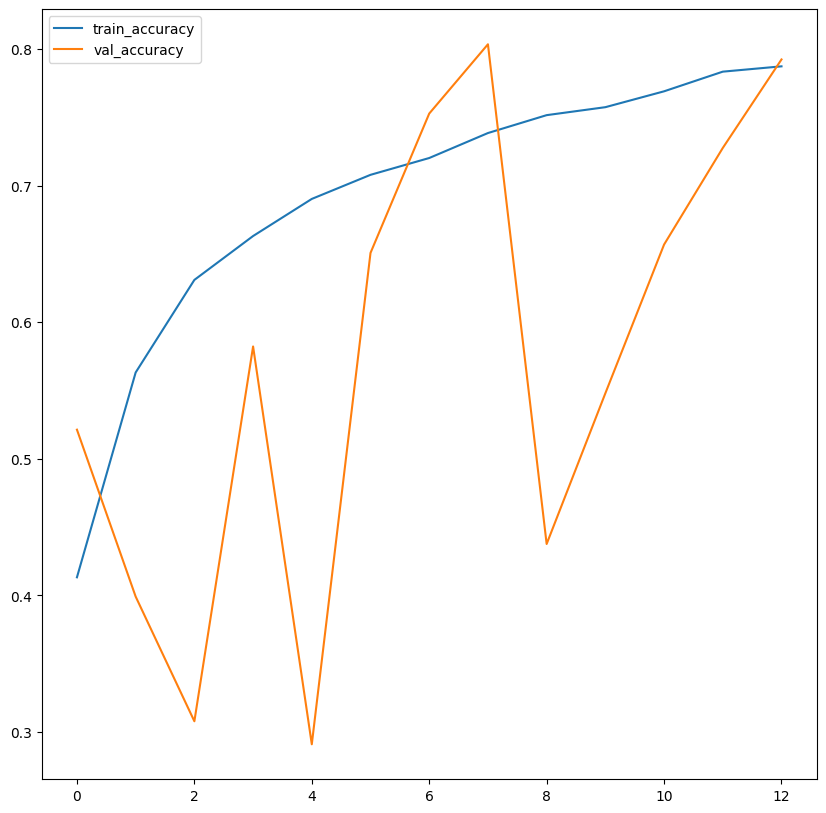

In [36]:
plt.figure(figsize=(10,10))

plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

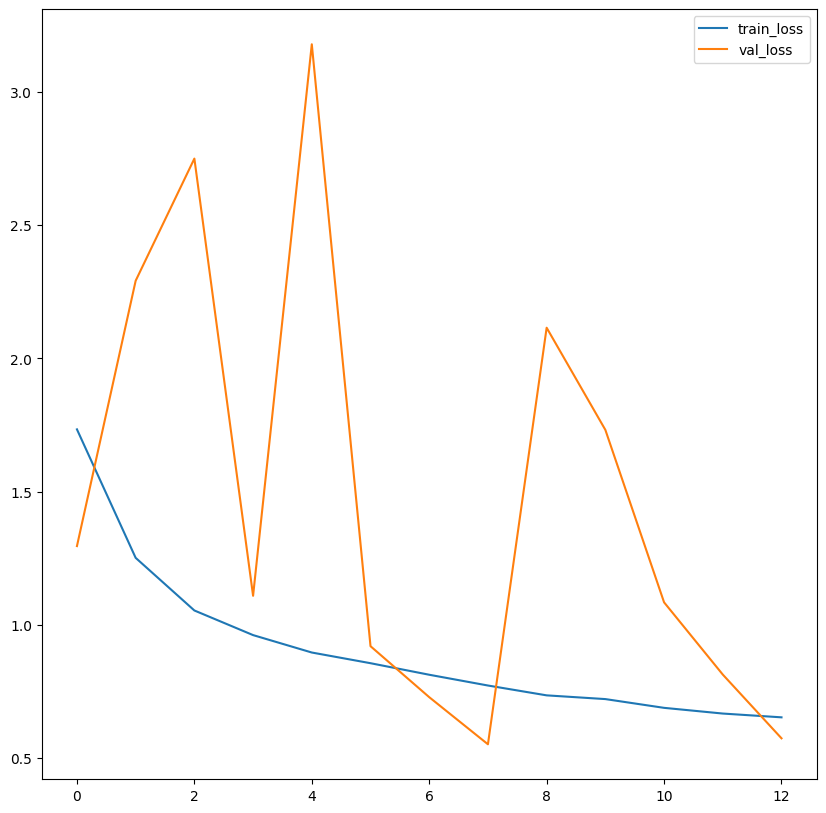

In [37]:
plt.figure(figsize=(10,10))

plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [38]:
y_true=[]
y_pred=[]

for images, labels in val_dataset:
  y_true.append(labels.numpy())
  y_pred.append(np.argmax(model.predict(images),axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true_flat = np.concatenate(y_true)
y_pred_flat = np.concatenate(y_pred)

print(classification_report(y_true_flat, y_pred_flat, target_names=class_names))

                      precision    recall  f1-score   support

          AnnualCrop       0.86      0.85      0.86       597
              Forest       0.94      0.93      0.94       600
HerbaceousVegetation       0.78      0.61      0.68       557
             Highway       0.61      0.43      0.51       493
          Industrial       0.89      0.92      0.91       512
             Pasture       0.77      0.78      0.78       374
       PermanentCrop       0.60      0.74      0.66       491
         Residential       0.81      0.99      0.89       607
               River       0.77      0.71      0.74       547
             SeaLake       0.89      0.97      0.93       622

            accuracy                           0.80      5400
           macro avg       0.79      0.79      0.79      5400
        weighted avg       0.80      0.80      0.80      5400



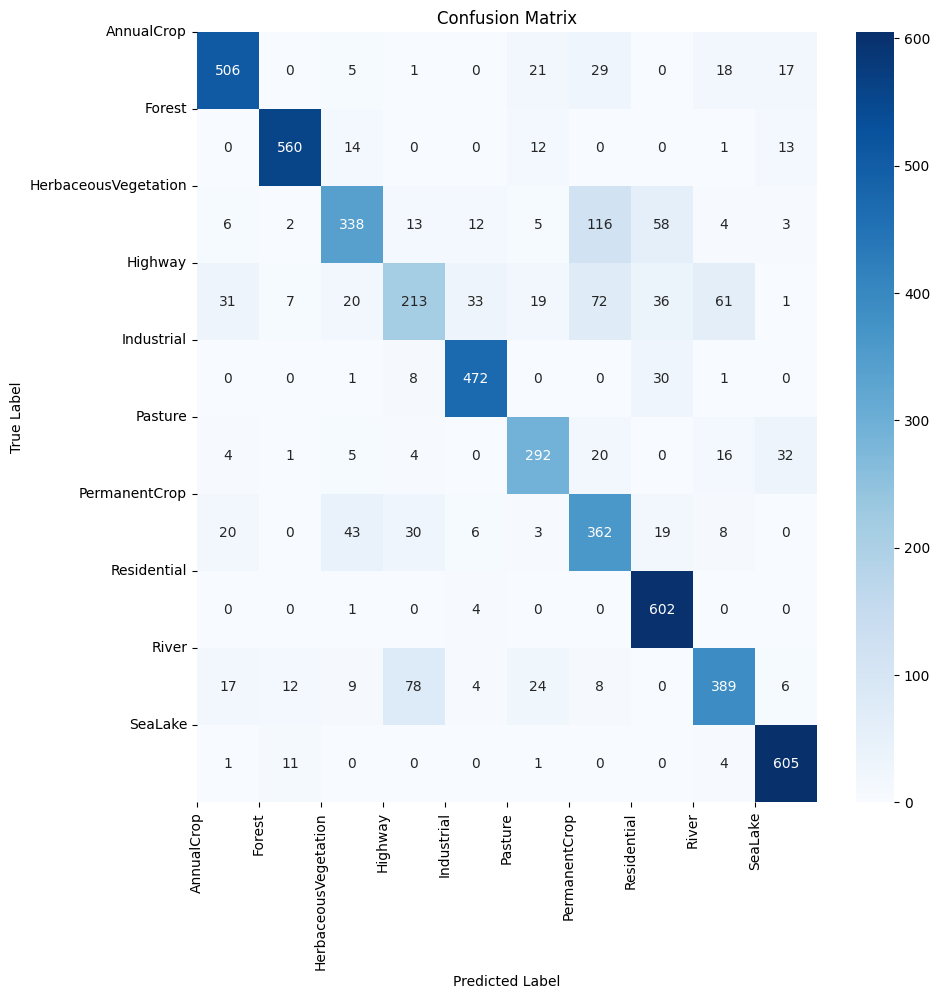

In [48]:
import seaborn as sns
import numpy as np

y_true_flat = np.concatenate(y_true)
y_pred_flat = np.concatenate(y_pred)

cm=confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xticks(np.arange(10),class_names,rotation=90)
plt.yticks(np.arange(10),class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Class: Pasture
Confidence: 0.5953887


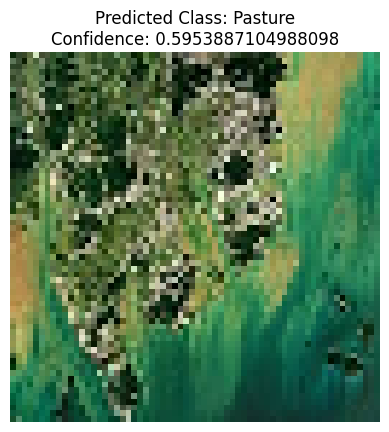

In [54]:
# prediction
image_path=r'/content/images.jpeg'

img=tf.keras.utils.load_img(image_path,target_size=(64,64))

img_array=tf.keras.utils.img_to_array(img)

img_array=img_array/255.0

img_array=tf.expand_dims(img_array,0)

prediction=model.predict(img_array)

predicted_class=class_names[np.argmax(prediction)]

confidence=np.max(prediction)

plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class}\nConfidence: {confidence}")
plt.axis("off")

print("Predicted Class:",predicted_class)
print("Confidence:",confidence)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class: Industrial
Confidence: 0.7550469


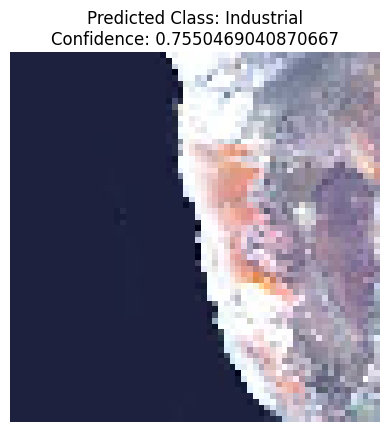

In [51]:
# prediction
image_path=r'/content/images (1).jpeg'

img=tf.keras.utils.load_img(image_path,target_size=(64,64))

img_array=tf.keras.utils.img_to_array(img)

img_array=img_array/255.0

img_array=tf.expand_dims(img_array,0)

prediction=model.predict(img_array)

predicted_class=class_names[np.argmax(prediction)]

confidence=np.max(prediction)

plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class}\nConfidence: {confidence}")
plt.axis("off")

print("Predicted Class:",predicted_class)
print("Confidence:",confidence)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class: Residential
Confidence: 0.51079416


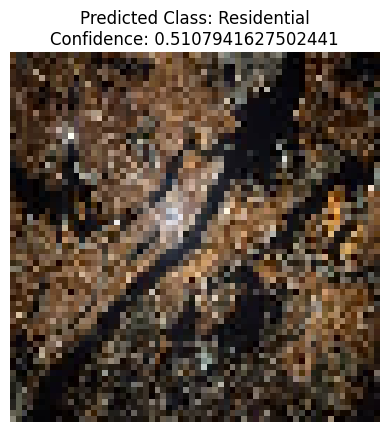

In [52]:
# prediction
image_path=r'/content/images (2).jpeg'

img=tf.keras.utils.load_img(image_path,target_size=(64,64))

img_array=tf.keras.utils.img_to_array(img)

img_array=img_array/255.0

img_array=tf.expand_dims(img_array,0)

prediction=model.predict(img_array)

predicted_class=class_names[np.argmax(prediction)]

confidence=np.max(prediction)

plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class}\nConfidence: {confidence}")
plt.axis("off")

print("Predicted Class:",predicted_class)
print("Confidence:",confidence)
plt.show()

In [55]:
# pretrained ResNet50
base_model=tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(64,64,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [56]:
base_model.trainable=False

In [57]:
from tensorflow.keras.layers import GlobalAveragePooling2D
resnet_model=Sequential(
    [
        data_augumentation,
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512,activation="relu"),
        Dropout(0.5),
        Dense(256,activation='relu'),
        Dropout(0.3),
        Dense(10,activation='softmax')
    ]
)

In [58]:
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 64, 64, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (32, 2, 2, 2048)       │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 2048)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 2048)             │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 512)              │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 512)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 256)              │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 10)               │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,778,890 (94.52 MB)

 Trainable params: 1,187,082 (4.53 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [59]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
early_stop_resnet=EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

checkpoint_resnet=ModelCheckpoint(
    filepath='resnet_model.h5',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
)

In [ ]:
history_resnet= resnet_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop_resnet,checkpoint_resnet]
)

Epoch 1/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.4319 - loss: 1.5546
Epoch 1: val_accuracy improved from None to 0.51148, saving model to resnet_model.h5



Epoch 1: finished saving model to resnet_model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 195s 282ms/step - accuracy: 0.4816 - loss: 1.4172 - val_accuracy: 0.5115 - val_loss: 1.3112
Epoch 2/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5382 - loss: 1.2528
Epoch 2: val_accuracy improved from 0.51148 to 0.53333, saving model to resnet_model.h5



Epoch 2: finished saving model to resnet_model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 189s 280ms/step - accuracy: 0.5487 - loss: 1.2308 - val_accuracy: 0.5333 - val_loss: 1.2747
Epoch 3/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5689 - loss: 1.1801
Epoch 3: val_accuracy improved from 0.53333 to 0.59574, saving model to resnet_model.h5



Epoch 3: finished saving model to resnet_model.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 189s 280ms/step - accuracy: 0.5700 - loss: 1.1749 - val_accuracy: 0.5957 - val_loss: 1.1479
Epoch 4/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5802 - loss: 1.1505
Epoch 4: val_accuracy did not improve from 0.59574
675/675 ━━━━━━━━━━━━━━━━━━━━ 189s 280ms/step - accuracy: 0.5799 - loss: 1.1519 - val_accuracy: 0.5685 - val_loss: 1.1765
Epoch 5/20
666/675 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accuracy: 0.5909 - loss: 1.1433

In [ ]:
loss_resnet,accuracy_resnet=resnet_model.evaluate(val_dataset)
print("Loss",loss_resnet)
print("Accuracy",accuracy_resnet)

In [ ]:
# accuracy comparision
plt.figure(figsize=(8,5))

plt.plot(
    history.history['val_accuracy'],
    label='Custom CNN'
)

plt.plot(
    history_resnet.history['val_accuracy'],
    label='ResNET50 Accuracy'
)
plt.xlabel("Epochs")

plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparision")
plt.legend()
plt.grid(true)
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['val_loss'],
    label='Custom CNN'
)

plt.plot(
    history_resnet.history['val_loss'],
    label='ResNET50 Loss'
)
plt.xlabel("Epochs")

plt.ylabel("Loss")
plt.title("Validation Loss Comparision")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# classification report
y_pred=[]
y_true=[]

for images,labels in val_dataset:

  predictions=resnet_model.predict(images)
  predicted=np.argmax(predictions,axis=1)
  y_pred.append(predicted)
  y_true.append(labels.numpy())

print(classification_report(y_true,y_pred,target_names=class_names))




In [ ]:
cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize(10,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xticks(np.arange(10),class_names,rotation=90)
plt.yticks(np.arange(10),class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
comparision=pd.DataFrame({
    'Model':['Custom CNN','ResNet50'],
    'Loss':[loss,loss_resnet],
    'Accuracy':[accuracy,accuracy_resnet]
})


In [ ]:
if accuracy_resnet>accuracy:
  print("ResNet50 is better")
else:
  print("Custom CNN is better")